# Test Pipeline

Small notebook for testing the extracted line-mode pipeline on one SWORD reach selection.

In [140]:
import importlib

from pathlib import Path

import geopandas as gpd
import numpy as np

import supporting_metrics as sm
import supporting_geometry as sg
import supporting_boundaries as sb
import supporting_plotting as sp
import reach_concatenation as rc
import main_pipeline as mp

importlib.reload(sm)
importlib.reload(sg)
importlib.reload(sb)
importlib.reload(sp)
importlib.reload(rc)
importlib.reload(mp)


<module 'main_pipeline' from '/Users/6256481/Code/single_thread_channel_hierarchy/main_pipeline.py'>

In [2]:
cont = 'SA'

In [15]:
GPKG_PATH = Path(f"/Volumes/PhD/SWORD/v17c/sword_{cont}_v17c_reaches.parquet")
TARGET_CRS = "EPSG:3857"

if not GPKG_PATH.exists():
    raise FileNotFoundError(f"Update GPKG_PATH; file not found: {GPKG_PATH}")

df = gpd.read_parquet(GPKG_PATH)
df = df.to_crs('EPSG:3857')
df.shape, df.crs

((42159, 113),
 <Projected CRS: EPSG:3857>
 Name: WGS 84 / Pseudo-Mercator
 Axis Info [cartesian]:
 - X[east]: Easting (metre)
 - Y[north]: Northing (metre)
 Area of Use:
 - name: World between 85.06°S and 85.06°N.
 - bounds: (-180.0, -85.06, 180.0, 85.06)
 Coordinate Operation:
 - name: Popular Visualisation Pseudo-Mercator
 - method: Popular Visualisation Pseudo Mercator
 Datum: World Geodetic System 1984
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [129]:
r = df[(df["main_path_id"].isin([6000703]))]
merged = rc.merge_mainpaths(r)
display(merged)
merged = merged['line'].iloc[0]

100%|██████████| 1/1 [00:00<00:00,  2.98it/s]


,main_path_id,line,is_multilinestring,reach_ids,input_geom_length,merged_geom_length,length_removed,length_loss_frac
0,6000703,"LINESTRING (-7205446.844732 -1782025.37546, -7...",False,"[62269700011, 62269700021, 62269700031, 622697...",1.439315e+06,1.439315e+06,-0.000003,-1.772296e-12


In [130]:
# merged = merge_paths_mainstem_only(reach)
reach = r
width_m = float(reach["width"].median())

print("reach rows:", len(reach))
print("median width:", round(width_m, 2))
print("merged geometry:", merged.geom_type)
print("merged length:", round(merged.length, 2))

reach rows: 143
median width: 42.0
merged geometry: LineString
merged length: 1439314.97


In [128]:
# import pandas as pd
pd.DataFrame(result["boundary_diagnostics"]["candidates"])[
    ["sigma", "score", "prominence", "decision", "reason", 'contrast']
]

,sigma,score,prominence,decision,reason,contrast
0,35.233372,0.003799,3.368438e-03,rejected,insufficient local jump,0.796229
1,108.588755,0.001375,5.520134e-04,rejected,below adaptive prominence floor,0.251060
2,262.945704,0.000827,4.050073e-06,rejected,below adaptive prominence floor,0.002453
3,951.764892,0.001140,3.172256e-04,rejected,below adaptive prominence floor,0.161567
4,5149.625613,0.002230,1.888817e-03,kept,selected boundary,0.734465
5,30195.213636,0.000425,4.636761e-07,rejected,below adaptive prominence floor,0.000546


In [153]:
max(80*width_m, merged.length)

1439314.9697360604

In [145]:
result = mp.extract_line_modes_auto(
    merged,
    width_m=width_m,
    make_plots=False,
    prune_dist_abs=width_m,
    use_threshold_sigmas_as_modes=False,  # default active family
    sigma_max=merged.length,
    n_sigmas=200
)


In [150]:
# sp.plot_thresholding_from_result(result, use_threshold_modes=False)
# sp.plot_modes_from_result(result, use_threshold_modes=False)


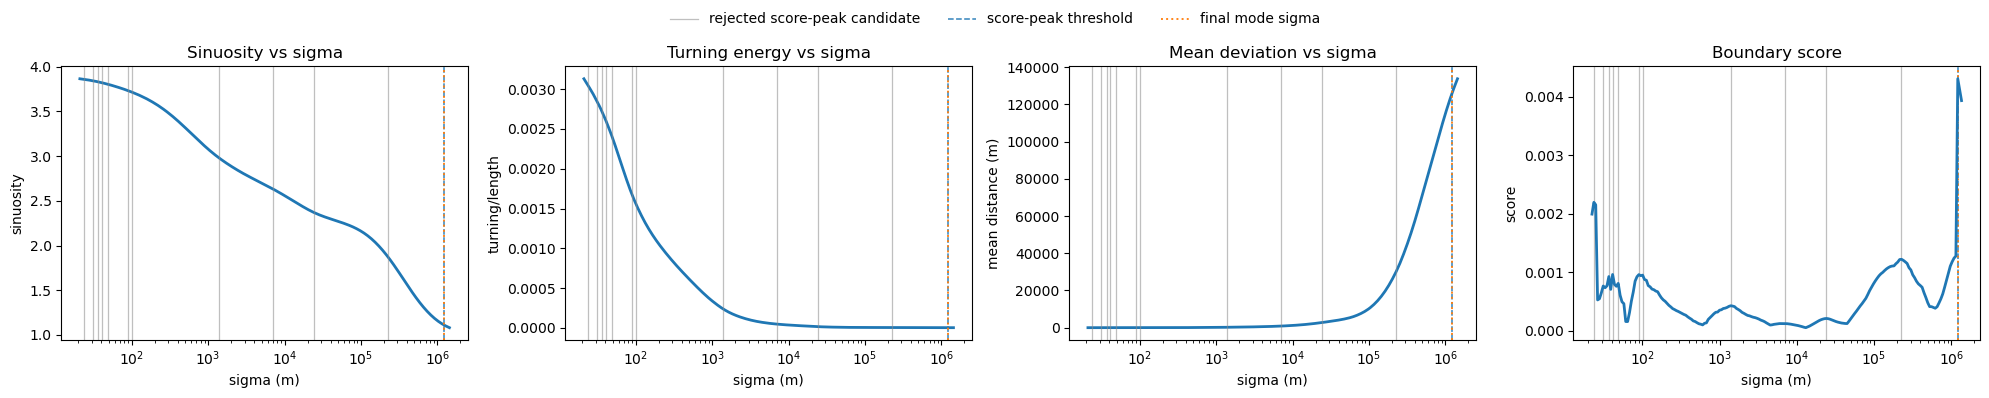

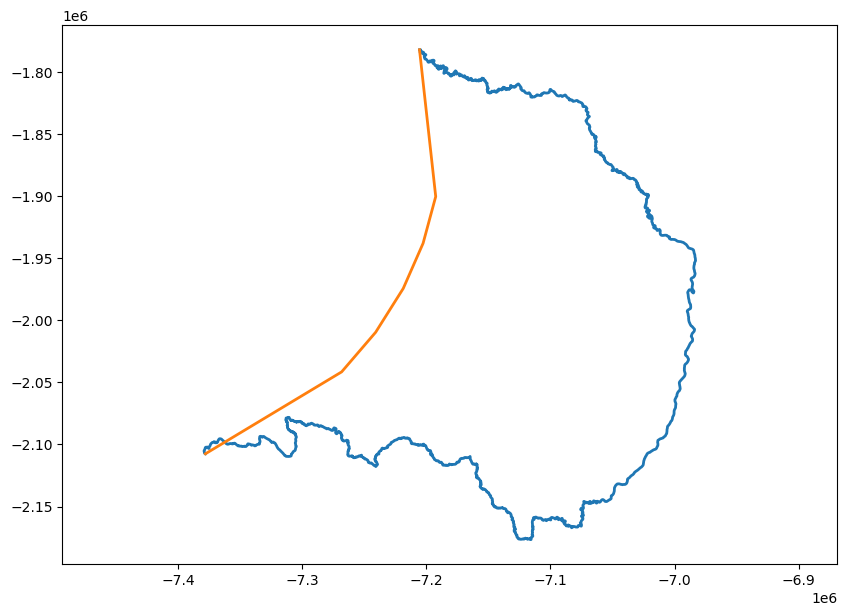

In [146]:
sp.plot_thresholding_from_result(result, use_threshold_modes=True)
sp.plot_modes_from_result(result, use_threshold_modes=True)


In [149]:
# plot_labels = [
#     f"{lbl} | sigma~{sig:.0f}m"
#     for lbl, sig in zip(result["stable_mode_labels"], result["stable_mode_sigmas"])
# ]
# fig = sp.plot_modes_plotly(
#     result["ls_equal"],
#     result["stable_modes"],
#     labels=plot_labels,
#     show=False,
# )
# fig.show()


In [148]:
# plot_labels = [
#     f"{lbl} | sigma~{sig:.0f}m"
#     for lbl, sig in zip(result["threshold_mode_labels"], result["threshold_mode_sigmas"])
# ]
# fig = sp.plot_modes_plotly(
#     result["ls_equal"],
#     result["threshold_modes"],
#     labels=plot_labels,
#     show=False,
# )
# fig.show()


In [147]:
import pandas as pd

cand = pd.DataFrame(result["boundary_diagnostics"]["candidates"])
cand[[
    "sigma",
    "score",
    "base_score",
    "prominence",
    "contrast",
    "prom_frac",
    "contrast_band",
    "passes_prominence_threshold",
    "passes_jump_gate",
    "passes_contrast_gate",
    "decision",
    "reason",
]]



,sigma,score,base_score,prominence,contrast,prom_frac,contrast_band,passes_prominence_threshold,passes_jump_gate,passes_contrast_gate,decision,reason
0,2.348668e+01,0.002195,0.000524,0.001672,0.614784,0.761444,high,True,False,False,rejected,insufficient local jump
1,3.106902e+01,0.000762,0.000732,0.000030,0.020305,0.039801,NaN,False,None,None,rejected,below adaptive prominence floor
2,3.674779e+01,0.000924,0.000732,0.000192,0.115968,0.207833,NaN,False,None,None,rejected,below adaptive prominence floor
3,4.109922e+01,0.000960,0.000757,0.000202,0.117761,0.210709,NaN,False,None,None,rejected,below adaptive prominence floor
4,4.861129e+01,0.000807,0.000757,0.000050,0.031966,0.061953,NaN,False,None,None,rejected,below adaptive prominence floor
5,8.996016e+01,0.000958,0.000939,0.000019,0.009859,0.019525,NaN,False,None,None,rejected,below adaptive prominence floor
6,1.006126e+02,0.000949,0.000939,0.000010,0.005185,0.010317,NaN,False,None,None,rejected,below adaptive prominence floor
7,1.395753e+03,0.000424,0.000097,0.000328,0.629401,0.772555,high,True,True,True,rejected,weaker than gap-ratio stop
8,7.072011e+03,0.000120,0.000094,0.000026,0.121548,0.216750,NaN,False,None,None,rejected,below adaptive prominence floor
9,2.421972e+04,0.000206,0.000119,0.000087,0.267444,0.422022,NaN,False,None,None,rejected,below adaptive prominence floor


In [49]:
result

{'ls_equal': <LINESTRING (-7356936.373 -1230777.132, -7356949.705 -1230784.005, -7356963....>,
 'step_m': 15.0,
 'width_m': 384.0,
 'distance_sampling': {'sample_count': 4000,
  'requested_count': None,
  'requested_spacing': 300.0,
  'actual_spacing': 321.6263580400428,
  'strategy': 'spacing_capped',
  'min_samples': 200,
  'max_samples': 4000},
 'sigmas': array([3.00000000e+01, 3.25115541e+01, 3.52333716e+01, 3.81830556e+01,
        4.13796826e+01, 4.48439263e+01, 4.85981911e+01, 5.26667573e+01,
        5.70759377e+01, 6.18542478e+01, 6.70325908e+01, 7.26444567e+01,
        7.87261394e+01, 8.53169713e+01, 9.24595776e+01, 1.00200152e+02,
        1.08588755e+02, 1.17679640e+02, 1.27531599e+02, 1.38208349e+02,
        1.49778941e+02, 1.62318205e+02, 1.75907236e+02, 1.90633921e+02,
        2.06593501e+02, 2.23889193e+02, 2.42632853e+02, 2.62945704e+02,
        2.84959116e+02, 3.08815457e+02, 3.34669015e+02, 3.62686993e+02,
        3.93050593e+02, 4.25956187e+02, 4.61616587e+02, 5.002624

In [51]:
from scipy.signal import savgol_filter, find_peaks


In [136]:
import pandas as pd
import numpy as np

cand = pd.DataFrame(result["boundary_diagnostics"]["candidates"])

row = cand.loc[cand["sigma"].sub(27.045139).abs().idxmin()]
k = int(row["sigma_idx"])         # index into sigmas / metrics
j = int(row["peak_score_idx"])    # index into score

print(row[[
    "sigma",
    "score",
    "base_score",
    "prominence",
    "contrast",
    "contrast_band",
    "local_jump_sinuosity",
    "local_jump_distance",
    "local_jump_turning",
    "passes_prominence_threshold",
    "passes_jump_gate",
    "passes_contrast_gate",
    "decision",
    "reason",
]])

print("jump thresholds:", result["boundary_diagnostics"]["effective_jump_thresholds"])

print("metric values at this sigma:")
print({
    "sigma": result["sigmas"][k],
    "sinuosity": result["metrics"]["sinuosity"][k],
    "turning": result["metrics"]["turning"][k],
    "dist_to_original": result["metrics"]["dist"][k],
    "score": result["score"][j],
})


sigma                                  27.045139
score                                   0.003985
base_score                              0.001451
prominence                              0.002534
contrast                                0.466149
contrast_band                               high
local_jump_sinuosity                    0.024214
local_jump_distance                     0.828033
local_jump_turning                      0.000291
passes_prominence_threshold                 True
passes_jump_gate                            True
passes_contrast_gate                        True
decision                                    kept
reason                         selected boundary
Name: 0, dtype: object
jump thresholds: {'sinuosity': 0.05, 'distance': 2061.9055478120713, 'turning': 0.0001563015588064709}
metric values at this sigma:
{'sigma': np.float64(27.04513916717558), 'sinuosity': np.float64(3.8525151414736447), 'turning': np.float64(0.0029564001210012477), 'dist_to_original': np.floa

In [92]:
dist = result['plot_data']['dist'][1:-1]
score = result['plot_data']['score']
d[(d>5000) & (d<5200)]

np.argwhere((d>900) & (d<1000))

# d[90:110]

array([[62],
       [63],
       [64]])

In [116]:
import numpy as np

score = np.asarray(score, float)

peaks, valleys = [], []
for i in range(1, len(score) - 1):
    if score[i - 1] < score[i] and score[i + 1] < score[i]:
        peaks.append(i)
    if score[i - 1] > score[i] and score[i + 1] > score[i]:
        valleys.append(i)

peaks = np.asarray(peaks, dtype=int)
valleys = np.asarray(valleys, dtype=int)

peak_info = []
for p in peaks:
    pos = np.searchsorted(valleys, p)

    left_v = valleys[pos - 1] if pos > 0 else None
    right_v = valleys[pos] if pos < len(valleys) else None

    if left_v is None and right_v is None:
        continue
    elif left_v is None:
        base = score[right_v]
    elif right_v is None:
        base = score[left_v]
    else:
        base = max(score[left_v], score[right_v])  # stricter baseline

    peak = score[p]
    prom = peak - base
    contrast = prom / (peak + base + 1e-12)
    prom_frac = prom / (peak + 1e-12)
    log_ratio = np.log((peak + 1e-12) / (base + 1e-12))

    peak_info.append({
        "peak_idx": int(p),
        "peak": float(peak),
        "base": float(base),
        "prominence": float(prom),
        "contrast": float(contrast),
        "prom_frac": float(prom_frac),
        "log_ratio": float(log_ratio),
    })

# example independent rule
kept = [
    d for d in peak_info
    if d["prominence"] >= 0.0008 and d["contrast"] >= 0.25
]


In [114]:
kept_peak_info

[{'peak_idx': 1,
  'peak_score': 0.003799463646677398,
  'left_valley_idx': None,
  'right_valley_idx': 7,
  'base_score': 0.00043102594692740246,
  'prominence': 8.814930223486849},
 {'peak_idx': 63,
  'peak_score': 0.002230254050223035,
  'left_valley_idx': 51,
  'right_valley_idx': 79,
  'base_score': 0.0003414368128415654,
  'prominence': 6.531967164471877}]

In [117]:
peak_info

[{'peak_idx': 1,
  'peak': 0.003799463646677398,
  'base': 0.00043102594692740246,
  'prominence': 0.0033684376997499955,
  'contrast': 0.7962288109739848,
  'prom_frac': 0.8865561068886953,
  'log_ratio': 2.1764468981050284},
 {'peak_idx': 15,
  'peak': 0.001375374074584174,
  'base': 0.0008233606967066209,
  'prominence': 0.0005520133778775532,
  'contrast': 0.25105955699351007,
  'prom_frac': 0.4013550841745305,
  'log_ratio': 0.5130866515882144},
 {'peak_idx': 26,
  'peak': 0.000827410769762798,
  'base': 0.0008233606967066209,
  'prominence': 4.050073056177119e-06,
  'contrast': 0.0024534426091006737,
  'prom_frac': 0.004894875918092434,
  'log_ratio': 0.004906895060734362},
 {'peak_idx': 42,
  'peak': 0.0011403292178029873,
  'base': 0.0008231035876502083,
  'prominence': 0.000317225630152779,
  'contrast': 0.16156683799422958,
  'prom_frac': 0.2781877592207742,
  'log_ratio': 0.32599022823170165},
 {'peak_idx': 63,
  'peak': 0.002230254050223035,
  'base': 0.0003414368128415654,

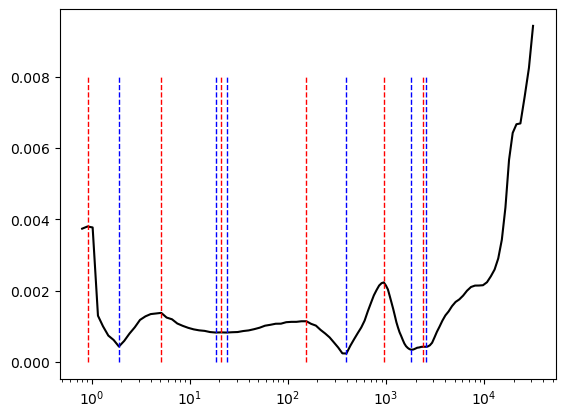

In [109]:
import matplotlib.pyplot as plt
plt.plot(d, result['plot_data']['score'], color = 'black')
for p in peak:
    plt.vlines(dist[p], 0.0, 0.008, linestyles='--', linewidth = 1, color = 'red')
for p in valley:
    plt.vlines(dist[p], 0.0, 0.008, linestyles='--', linewidth = 1, color = 'blue')
plt.xscale('log')

In [47]:
import pandas as pd

# import pandas as pd
pd.DataFrame(result["boundary_diagnostics"]["candidates"])[
    ["sigma", "score", "prominence", "decision", "reason"]
]



,sigma,score,prominence,decision,reason
0,35.233372,0.003799,0.003368,rejected,insufficient local jump
1,108.588755,0.001375,NaN,rejected,below score percentile
2,262.945704,0.000827,NaN,rejected,below score percentile
3,951.764892,0.001140,NaN,rejected,below score percentile
4,5149.625613,0.002230,0.001995,rejected,below prominence percentile
5,30195.213636,0.000425,NaN,rejected,below score percentile


In [33]:
result["prune_diagnostics"]

{'settings': {'dist_abs': 384.0,
  'dist_w_frac': 0.3,
  'turn_frac_min': 0.15,
  'sc_frac_min': 0.2,
  'sinu_abs_min': 0.04,
  'dist_sample_spacing': 300.0,
  'dist_min_samples': 200,
  'dist_max_samples': 4000},
 'candidates': [{'candidate_index': 0,
   'sigma': 1962.356715501377,
   'comparison_basis': 'original',
   'distance': 408.02824085061474,
   'distance_threshold': 1152.0,
   'distance_pass': False,
   'turn_drop_frac': None,
   'sign_change_drop_frac': None,
   'sinuosity_drop_abs': None,
   'kept': False,
   'reason': 'failed distance gate',
   'distance_sampling': {'sample_count': 4000,
    'requested_count': None,
    'requested_spacing': 300.0,
    'actual_spacing': 321.6263580400428,
    'strategy': 'spacing_capped',
    'min_samples': 200,
    'max_samples': 4000}},
  {'candidate_index': 1,
   'sigma': 15871.073631037598,
   'comparison_basis': 'original',
   'distance': 1686.8558222200247,
   'distance_threshold': 1152.0,
   'distance_pass': True,
   'turn_drop_frac'

In [32]:
result['mode_sigmas'] / result['width_m']

array([  41.33092091, 1030.22974086])